<a href="https://colab.research.google.com/github/sravananambiar20/FinSight/blob/main/FinSight_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel(
    "/content/personal_transactions_dashboard_ready (2).xlsx"
)

df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [ ]:
df.shape

(806, 7)

In [ ]:
df.columns

Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name', 'Month'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
 6   Month             806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 44.2+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Description,0
Amount,0
Transaction Type,0
Category,0
Account Name,0
Month,0


The dataset contains no missing values in the seven transaction attributes.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Transaction Type"].value_counts()

,count
Transaction Type,
debit,688
credit,118


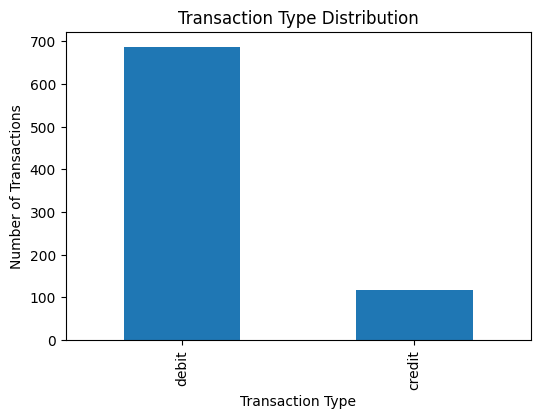

In [ ]:
df["Transaction Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

**Total income**

In [ ]:
total_income = df.loc[
    df["Transaction Type"] == "credit",
    "Amount"
].sum()

total_income

np.float64(124269.76000000001)

**Total expenses**

In [ ]:
total_expenses = df.loc[
    df["Transaction Type"] == "debit",
    "Amount"
].sum()

total_expenses

np.float64(96083.78)

**Balance**

In [ ]:
balance = total_income - total_expenses

balance

np.float64(28185.98000000001)

**Savings rate**

In [ ]:
savings_rate = (
    balance / total_income
) * 100

savings_rate

np.float64(22.681286259827015)

**Summary**

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Income",
        "Total Expenses",
        "Balance",
        "Savings Rate"
    ],

    "Value": [
        total_income,
        total_expenses,
        balance,
        savings_rate
    ]
})

summary

,Metric,Value
0,Total Income,124269.760000
1,Total Expenses,96083.780000
2,Balance,28185.980000
3,Savings Rate,22.681286


**Analyze categories**

In [ ]:
df["Category"].value_counts()

,count
Category,
Credit Card Payment,143
Groceries,105
Restaurants,81
Utilities,63
Shopping,60
Gas & Fuel,52
Paycheck,46
Home Improvement,36
Coffee Shops,31


**Spending by category**

In [ ]:
category_spending = (
    df[df["Transaction Type"] == "debit"]
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_spending

,Amount
Category,
Credit Card Payment,33041.36
Mortgage & Rent,24754.50
Home Improvement,19092.87
Groceries,2795.21
Utilities,2776.00
Restaurants,2613.02
Shopping,1973.24
Gas & Fuel,1715.17
Mobile Phone,1680.40


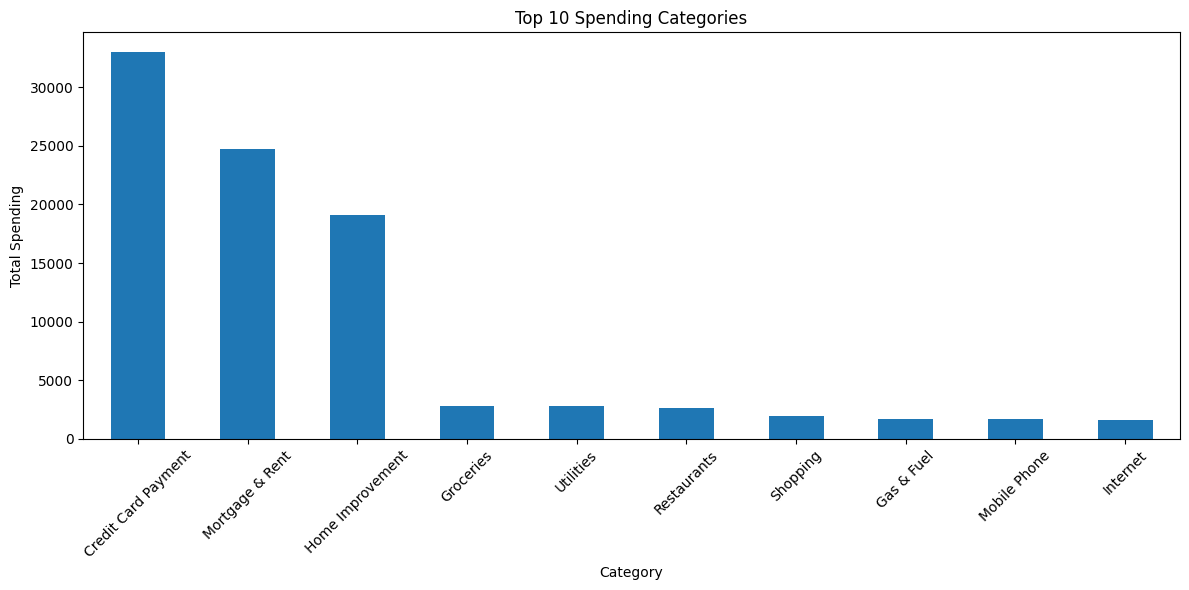

In [ ]:
plt.figure(figsize=(12,6))

category_spending.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Spending Categories")
plt.xlabel("Category")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Monthly spending**

In [ ]:
monthly_spending = (
    df[df["Transaction Type"] == "debit"]
    .groupby("Month")["Amount"]
    .sum()
)

monthly_spending

,Amount
Month,
2018-01,2931.45
2018-02,3165.05
2018-03,3500.16
2018-04,6029.54
2018-05,11392.03
2018-06,3665.88
2018-07,2968.98
2018-08,2396.18
2018-09,3286.99


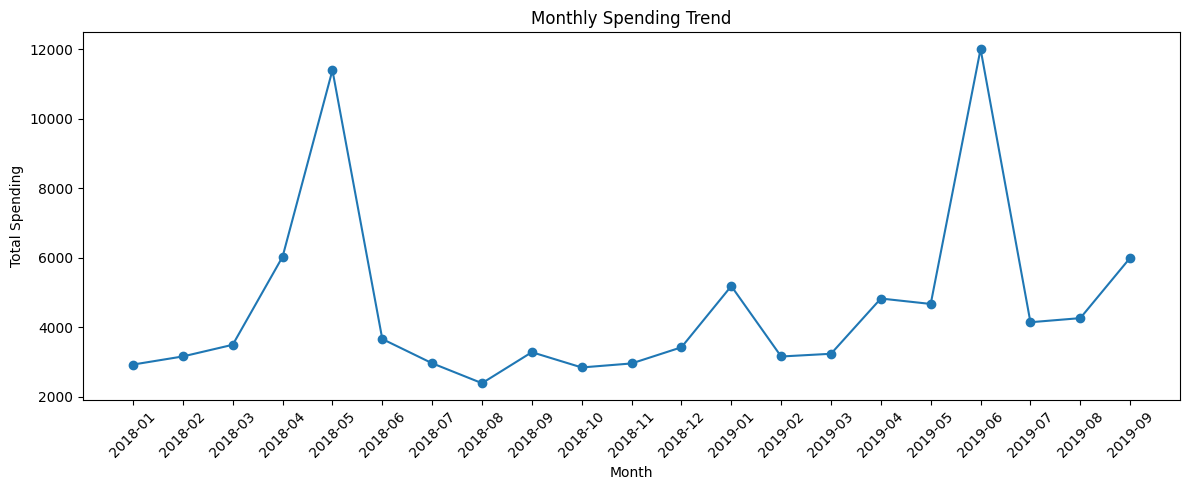

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_spending.index,
    monthly_spending.values,
    marker="o"
)

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Income vs expense overtime**

In [ ]:
monthly_income = (
    df[df["Transaction Type"] == "credit"]
    .groupby("Month")["Amount"]
    .sum()
)

monthly_expenses = (
    df[df["Transaction Type"] == "debit"]
    .groupby("Month")["Amount"]
    .sum()
)

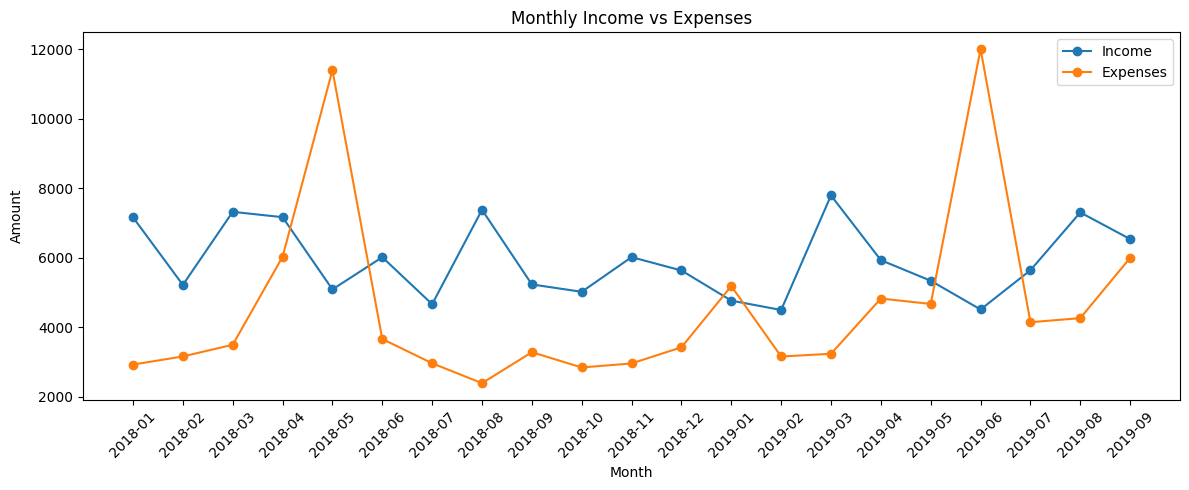

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_income.index,
    monthly_income.values,
    marker="o",
    label="Income"
)

plt.plot(
    monthly_expenses.index,
    monthly_expenses.values,
    marker="o",
    label="Expenses"
)

plt.title("Monthly Income vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

**Top 10 transactions**

In [ ]:
top_transactions = (
    df.sort_values(
        "Amount",
        ascending=False
    )
    .head(10)
)

top_transactions[
    [
        "Date",
        "Description",
        "Amount",
        "Transaction Type",
        "Category"
    ]
]

,Date,Description,Amount,Transaction Type,Category
676,2019-06-20,Mike's Construction Co.,9200.00,debit,Home Improvement
172,2018-05-11,Mike's Construction Co.,8000.00,debit,Home Improvement
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck
692,2019-07-05,Biweekly Paycheck,2250.00,credit,Paycheck
746,2019-08-16,Biweekly Paycheck,2250.00,credit,Paycheck
727,2019-08-02,Biweekly Paycheck,2250.00,credit,Paycheck
713,2019-07-19,Biweekly Paycheck,2250.00,credit,Paycheck
762,2019-08-30,Biweekly Paycheck,2250.00,credit,Paycheck
784,2019-09-13,Biweekly Paycheck,2250.00,credit,Paycheck


*Day 2*

In [ ]:
df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [ ]:
df.columns

Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name', 'Month'],
      dtype='object')

In [ ]:
df.shape

(806, 7)

**Expense Categorization**

Building a machine-learning category predictor

In [ ]:
df['Category'].value_counts()

,count
Category,
Credit Card Payment,143
Groceries,105
Restaurants,81
Utilities,63
Shopping,60
Gas & Fuel,52
Paycheck,46
Home Improvement,36
Coffee Shops,31


**Complete category information**

In [ ]:
print("Number of categories:", df['Category'].nunique())

print("\nCategory counts:")
print(df['Category'].value_counts())

Number of categories: 22

Category counts:
Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Internet                   21
Mortgage & Rent            21
Mobile Phone               21
Music                      21
Movies & Dvds              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64


In [ ]:
print("\nCategories with fewer than 5 transactions:")
print(df['Category'].value_counts()[df['Category'].value_counts() < 5])


Categories with fewer than 5 transactions:
Category
Electronics & Software    4
Food & Dining             2
Entertainment             1
Name: count, dtype: int64


**Prepare Data for ML**

In [ ]:
ml_df = df[df['Category'].map(df['Category'].value_counts()) >= 5].copy()

print("Original dataset:", df.shape)
print("ML dataset:", ml_df.shape)

Original dataset: (806, 7)
ML dataset: (799, 7)


In [ ]:
ml_df['Category'].value_counts()

,count
Category,
Credit Card Payment,143
Groceries,105
Restaurants,81
Utilities,63
Shopping,60
Gas & Fuel,52
Paycheck,46
Home Improvement,36
Coffee Shops,31


**Prepare training and testing data**

In [ ]:
X = ml_df['Description']
y = ml_df['Category']

print("Number of transactions:", len(X))
print("Number of categories:", y.nunique())

Number of transactions: 799
Number of categories: 19


X = the information the model uses to make a prediction → Description
y = the answer we want the model to predict → Category

**Split the data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 639
Testing samples: 160


**TF-IDF Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (639, 79)
Testing TF-IDF shape: (160, 79)


**Train the Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
category_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

category_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


**Evaluate the Model**

In [ ]:
y_pred = category_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 160


**Calculate accuracy**


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 97.5 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                     precision    recall  f1-score   support

     Alcohol & Bars       1.00      1.00      1.00         5
     Auto Insurance       1.00      1.00      1.00         4
       Coffee Shops       1.00      1.00      1.00         6
Credit Card Payment       1.00      1.00      1.00        29
          Fast Food       1.00      1.00      1.00         3
         Gas & Fuel       1.00      0.90      0.95        10
          Groceries       1.00      1.00      1.00        21
            Haircut       1.00      1.00      1.00         3
   Home Improvement       1.00      1.00      1.00         7
           Internet       1.00      1.00      1.00         4
       Mobile Phone       1.00      1.00      1.00         4
    Mortgage & Rent       1.00      1.00      1.00         4
      Movies & Dvds       0.67      1.00      0.80         4
              Music       1.00      1.00      1.00         4
           Paycheck       1.00      1.00      1.00         9
        Restaurants    

Precision → how many predicted transactions were actually correct

Recall → how many transactions of a category the model successfully found

F1-score → balance between precision and recall

Support → number of test transactions belonging to each category

In [ ]:
print("Duplicate descriptions:", ml_df['Description'].duplicated().sum())

print("\nUnique descriptions:", ml_df['Description'].nunique())

print("\nTotal descriptions:", len(ml_df))

Duplicate descriptions: 735

Unique descriptions: 64

Total descriptions: 799


**Check descriptions with multiple categories**

In [ ]:
description_category_counts = (
    ml_df.groupby('Description')['Category']
    .nunique()
    .sort_values(ascending=False)
)

print("Descriptions associated with multiple categories:")
print(description_category_counts[description_category_counts > 1])

Descriptions associated with multiple categories:
Description
American Tavern    2
Brewing Company    2
Netflix            2
Pizza Place        2
Starbucks          2
Name: Category, dtype: int64


In [ ]:
print(
    "Number of descriptions with multiple categories:",
    (description_category_counts > 1).sum()
)

Number of descriptions with multiple categories: 5


In [ ]:
import os

os.makedirs("models", exist_ok=True)

print("models folder created successfully!")

models folder created successfully!


In [ ]:
import joblib

joblib.dump(category_model, "models/category_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("Category model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Category model saved successfully!
TF-IDF vectorizer saved successfully!


In [ ]:
import os

print(os.listdir("models"))

['category_model.pkl', 'tfidf_vectorizer.pkl']


**Anomaly Detection using isolation forest**

The idea is to find transactions that look unusual compared with normal spending.

In [50]:
print("Amount statistics:")
print(df['Amount'].describe())

Amount statistics:
count     806.000000
mean      273.391489
std       667.630374
min         1.750000
25%        15.687500
50%        37.480000
75%       117.680000
max      9200.000000
Name: Amount, dtype: float64


In [51]:
print("Minimum amount:", df['Amount'].min())
print("Maximum amount:", df['Amount'].max())

Minimum amount: 1.75
Maximum amount: 9200.0


**Check Transaction Types**

In [52]:
print("Transaction Type counts:")
print(df['Transaction Type'].value_counts())

Transaction Type counts:
Transaction Type
debit     688
credit    118
Name: count, dtype: int64


In [53]:
print("\nAmount statistics by transaction type:")
print(df.groupby('Transaction Type')['Amount'].describe())


Amount statistics by transaction type:
                  count         mean         std   min     25%      50%  \
Transaction Type                                                          
credit            118.0  1053.133559  842.241046  9.43  269.11  719.395   
debit             688.0   139.656657  528.335395  1.75   13.13   32.830   

                        75%      max  
Transaction Type                      
credit            2000.0000  2298.09  
debit               68.7025  9200.00  


**Prepare Expense Data for Anomaly Detection**

In [54]:
expense_df = df[df['Transaction Type'] == 'debit'].copy()

print("Total expense transactions:", len(expense_df))
print("\nTransaction types:")
print(expense_df['Transaction Type'].value_counts())

Total expense transactions: 688

Transaction types:
Transaction Type
debit    688
Name: count, dtype: int64


**Create the feature for Isolation Forest**

For the first anomaly model, we'll use the transaction amount as the numerical feature.

In [55]:
X_anomaly = expense_df[['Amount']]

print("Anomaly feature shape:", X_anomaly.shape)
print("\nFirst 5 values:")
print(X_anomaly.head())

Anomaly feature shape: (688, 1)

First 5 values:
    Amount
0    11.11
1  1247.44
2    24.22
4    11.76
5    25.85


**Train the Isolation Forest Model**

In [56]:
from sklearn.ensemble import IsolationForest

In [57]:
anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_model.fit(X_anomaly)

print("Isolation Forest model trained successfully!")

Isolation Forest model trained successfully!


**Generate anomaly predictions**

In [58]:
expense_df['Anomaly'] = anomaly_model.predict(X_anomaly)

print(expense_df['Anomaly'].value_counts())

Anomaly
 1    653
-1     35
Name: count, dtype: int64


**View the Anomalous Transactions**

In [59]:
anomalies = expense_df[expense_df['Anomaly'] == -1].copy()

print("Number of anomalies:", len(anomalies))

anomalies[['Date', 'Description', 'Amount', 'Category', 'Account Name']].sort_values(
    by='Amount',
    ascending=False
)

Number of anomalies: 35


,Date,Description,Amount,Category,Account Name
676,2019-06-20,Mike's Construction Co.,9200.00,Home Improvement,Checking
172,2018-05-11,Mike's Construction Co.,8000.00,Home Improvement,Checking
508,2019-01-31,Credit Card Payment,1900.00,Credit Card Payment,Checking
793,2019-09-18,Credit Card Payment,1606.46,Credit Card Payment,Checking
579,2019-04-01,Credit Card Payment,1552.65,Credit Card Payment,Checking
771,2019-09-06,Credit Card Payment,1390.37,Credit Card Payment,Checking
752,2019-08-19,Credit Card Payment,1248.95,Credit Card Payment,Checking
148,2018-04-26,Credit Card Payment,1216.94,Credit Card Payment,Checking
391,2018-11-02,Mortgage Payment,1209.18,Mortgage & Rent,Checking
356,2018-10-02,Mortgage Payment,1209.18,Mortgage & Rent,Checking


**Add Anomaly Score**

In [60]:
expense_df['Anomaly_Score'] = anomaly_model.decision_function(X_anomaly)

print(expense_df[['Amount', 'Anomaly', 'Anomaly_Score']].head())

    Amount  Anomaly  Anomaly_Score
0    11.11        1       0.237218
1  1247.44        1       0.000175
2    24.22        1       0.237495
4    11.76        1       0.242586
5    25.85        1       0.233885


**Display the most unusual transactions**

In [61]:
most_unusual = expense_df.sort_values(
    by='Anomaly_Score',
    ascending=True
)

most_unusual[
    ['Date', 'Description', 'Amount', 'Category', 'Anomaly', 'Anomaly_Score']
].head(10)

,Date,Description,Amount,Category,Anomaly,Anomaly_Score
676,2019-06-20,Mike's Construction Co.,9200.00,Home Improvement,-1,-0.255076
172,2018-05-11,Mike's Construction Co.,8000.00,Home Improvement,-1,-0.248569
508,2019-01-31,Credit Card Payment,1900.00,Credit Card Payment,-1,-0.169791
793,2019-09-18,Credit Card Payment,1606.46,Credit Card Payment,-1,-0.140541
579,2019-04-01,Credit Card Payment,1552.65,Credit Card Payment,-1,-0.134776
771,2019-09-06,Credit Card Payment,1390.37,Credit Card Payment,-1,-0.087142
233,2018-06-25,Credit Card Payment,942.76,Credit Card Payment,-1,-0.070952
112,2018-04-02,Credit Card Payment,817.14,Credit Card Payment,-1,-0.056963
708,2019-07-18,Credit Card Payment,814.50,Credit Card Payment,-1,-0.054210
356,2018-10-02,Mortgage Payment,1209.18,Mortgage & Rent,-1,-0.047256


**Save the Model**

In [62]:
joblib.dump(anomaly_model, "models/anomaly_model.pkl")

print("Anomaly model saved successfully!")

Anomaly model saved successfully!


In [63]:
import os

print(os.listdir("models"))

['category_model.pkl', 'anomaly_model.pkl', 'tfidf_vectorizer.pkl']
